In [9]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.preprocessing import load_data, prepare_features_target, split_data, print_data_info
from src.models import create_models, train_and_evaluate, compare_models, get_best_model

print("=" * 50)
print("Data Preparation")
print("=" * 50)

df = load_data()
X, y = prepare_features_target(df)
X_train, X_test, y_train, y_test = split_data(X, y)

print_data_info(X_train, X_test, y_train, y_test)


Data Preparation
Training set size: 16512 houses
Test set size: 4128 houses
Training features: 8

Train/Test ratio: 4.00:1


In [10]:
print("=" * 50)
print("Model Training")
print("=" * 50)

models = create_models()
results = train_and_evaluate(models, X_train, X_test, y_train, y_test)

for name, metrics in results.items():
    print(f"\n{name}")
    print(f"  Train MAE:  {metrics['train_mae']:.3f}")
    print(f"  Test MAE:   {metrics['test_mae']:.3f}")
    print(f"  Train RMSE: {metrics['train_rmse']:.3f}")
    print(f"  Test RMSE:  {metrics['test_rmse']:.3f}")
    print(f"  Train R2:   {metrics['train_r2']:.3f}")
    print(f"  Test R2:    {metrics['test_r2']:.3f}")


Model Training

Linear Regression
  Train MAE:  0.529
  Test MAE:   0.533
  Train RMSE: 0.720
  Test RMSE:  0.746
  Train R2:   0.613
  Test R2:    0.576

Decision Tree
  Train MAE:  0.000
  Test MAE:   0.455
  Train RMSE: 0.000
  Test RMSE:  0.704
  Train R2:   1.000
  Test R2:    0.622

Random Forest
  Train MAE:  0.122
  Test MAE:   0.328
  Train RMSE: 0.188
  Test RMSE:  0.505
  Train R2:   0.974
  Test R2:    0.805

Gradient Boosting
  Train MAE:  0.357
  Test MAE:   0.372
  Train RMSE: 0.511
  Test RMSE:  0.542
  Train R2:   0.805
  Test R2:    0.776


In [11]:
comparison_df = compare_models(results)
best_model_name, best_model = get_best_model(results, comparison_df)

print("=" * 50)
print("Model Comparison")
print("=" * 50)
print(comparison_df)
print(f"\nBest model: {best_model_name}")

best_predictions = results[best_model_name]['y_test_pred']


Model Comparison
                      Train MAE  Test MAE    Train RMSE  Test RMSE  Train R2  \
Random Forest      1.220567e-01  0.327543  1.879562e-01   0.505340  0.973573   
Gradient Boosting  3.566327e-01  0.371643  5.106939e-01   0.542215  0.804898   
Decision Tree      4.593655e-17  0.454679  3.218326e-16   0.703729  1.000000   
Linear Regression  5.286284e-01  0.533200  7.196757e-01   0.745581  0.612551   

                    Test R2  
Random Forest      0.805123  
Gradient Boosting  0.775645  
Decision Tree      0.622076  
Linear Regression  0.575788  

Best model: Random Forest


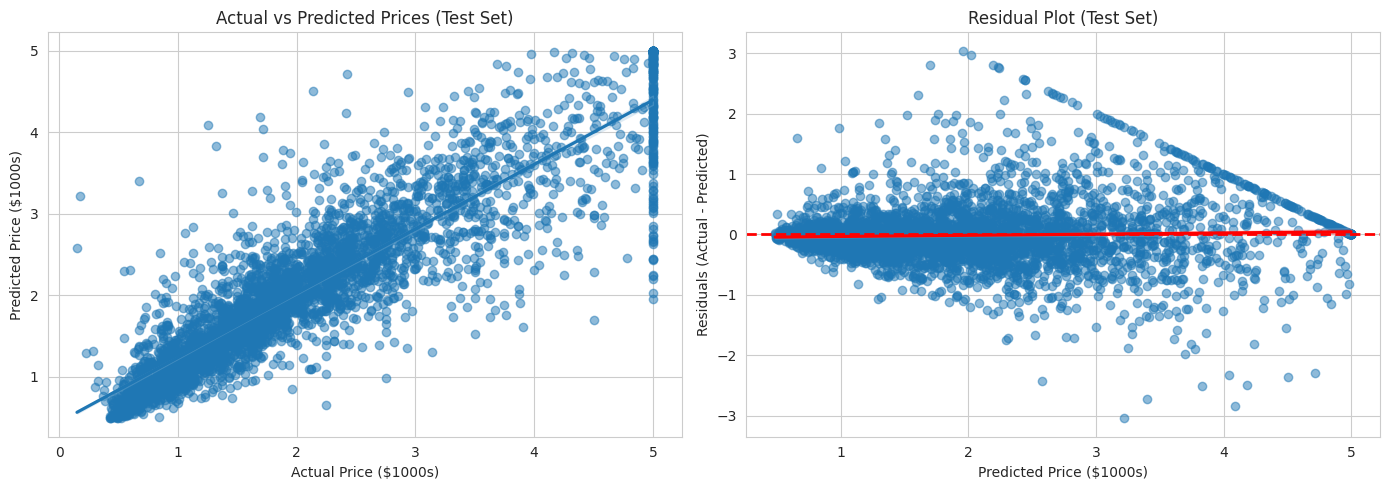

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(x=y_test, y=best_predictions, ax=axes[0], scatter_kws={'alpha': 0.5})
axes[0].set_xlabel('Actual Price ($1000s)')
axes[0].set_ylabel('Predicted Price ($1000s)')
axes[0].set_title('Actual vs Predicted Prices (Test Set)')

residuals = y_test - best_predictions
sns.regplot(x=best_predictions, y=residuals, ax=axes[1], scatter_kws={'alpha': 0.5}, line_kws={'color': 'r'})
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($1000s)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot (Test Set)')

plt.tight_layout()
plt.show()


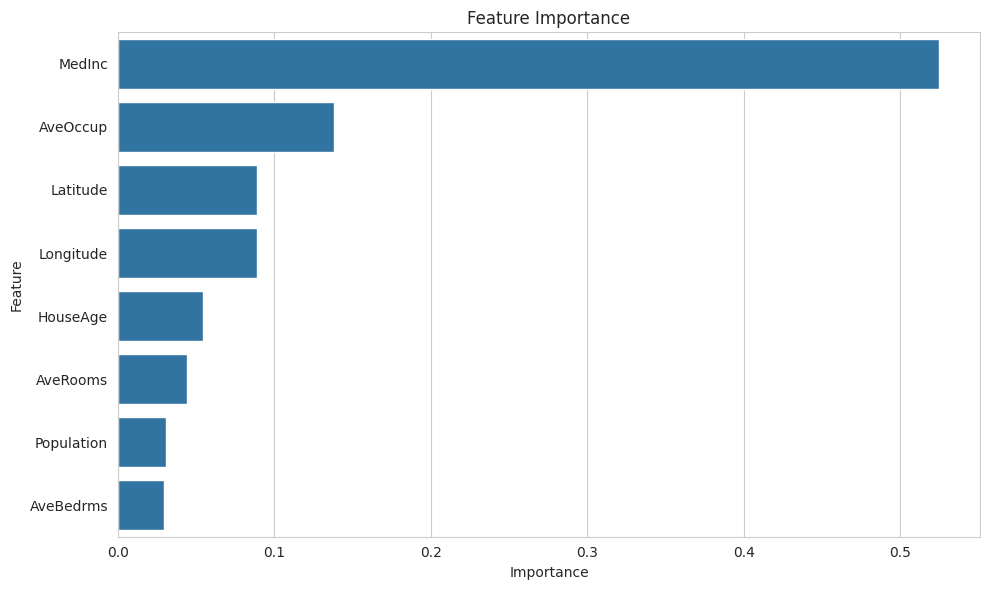

In [13]:
import pandas as pd
import numpy as np

feature_names = X.columns

if hasattr(best_model, 'coef_'):
    importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_model.coef_,
        'Abs_Importance': np.abs(best_model.coef_)
    }).sort_values('Abs_Importance', ascending=False)
    values = importance['Importance']
    labels = importance['Feature']
    title = 'Feature Importance (Linear Regression Coefficients)'
elif hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    values = importance['Importance']
    labels = importance['Feature']
    title = 'Feature Importance'
else:
    importance = None

if importance is not None:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=values, y=labels)
    plt.title(title)
    plt.tight_layout()
    plt.show()
